# One-seed candidate selection analysis

This notebook studies which currently unseeded vertex in Graph A should be queried next. For each of the three fixed problems, it joins pre-query candidate features with the SGM result obtained after adding that candidate.

The analysis has four parts:

1. Inspect candidate outcomes and feature associations.
2. Regress augmented $H_0$, final accuracy, and final-accuracy improvement.
3. Classify whether a candidate raises final unseeded accuracy to at least 90%.
4. Rank candidates and compare model choices with simple graph-based rules.

Only columns from `*_candidate_features.csv` are used as predictors. The candidate's revealed Graph B correspondence and every SGM result remain outcomes. Because there is currently one graph pair and one existing seed set per graph model, the train/test splits below measure exploratory within-problem discrimination. They do not establish generalization to new graph pairs.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    ndcg_score,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
TEST_FRACTION = 0.30
SUCCESS_THRESHOLD = 0.90
EXPECTED_FEATURE_SCHEMA_VERSION = 2

PROBLEMS = ("sparse_er", "sparse_sbm", "paper")
PROBLEM_LABELS = {
    "sparse_er": "Sparse ER",
    "sparse_sbm": "Sparse SBM",
    "paper": "PAPER",
}

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

## 1. Load and validate the candidate tables

The feature and outcome files are kept separate during collection. This cell validates their keys before joining them. Change `DATA_DIR` only if the generated files are stored somewhere else.

In [18]:
DATA_DIR = Path("data/one_seed_problems")

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_DIR.resolve()}. Run this notebook from the project root."
    )

feature_tables = {}
outcome_tables = {}
joined_tables = {}

OUTCOME_ONLY_COLUMNS = {
    "revealed_vertex_graph2",
    "baseline_h0_accuracy",
    "baseline_final_unseeded_accuracy",
    "outcome_h0_accuracy",
    "outcome_final_unseeded_accuracy",
    "outcome_final_all_accuracy",
    "outcome_accuracy_improvement",
    "outcome_success",
    "sgm_runtime_seconds",
    "sgm_n_iter",
    "sgm_converged",
    "sgm_objective_score",
}

for problem in PROBLEMS:
    feature_path = DATA_DIR / f"{problem}_candidate_features.csv"
    outcome_path = DATA_DIR / f"{problem}_candidate_outcomes.csv"

    features = pd.read_csv(feature_path)
    outcomes = pd.read_csv(outcome_path)
    join_keys = ["problem", "candidate_vertex_graph1"]

    if "feature_schema_version" not in features.columns:
        raise ValueError(
            f"{feature_path.name} uses the old feature schema. Refresh it with "
            "one_seed_problems.py --features-only before running the notebook."
        )
    schema_versions = set(features["feature_schema_version"].dropna().astype(int))
    if schema_versions != {EXPECTED_FEATURE_SCHEMA_VERSION}:
        raise ValueError(
            f"Expected feature schema {EXPECTED_FEATURE_SCHEMA_VERSION} in "
            f"{feature_path.name}, but found {sorted(schema_versions)}."
        )

    assert not features.duplicated(join_keys).any(), f"Duplicate feature rows for {problem}"
    assert not outcomes.duplicated(join_keys).any(), f"Duplicate outcome rows for {problem}"
    assert not (OUTCOME_ONLY_COLUMNS & set(features.columns)), (
        f"Outcome leakage found in the feature table for {problem}"
    )

    joined = features.merge(outcomes, on=join_keys, how="inner", validate="one_to_one")
    assert len(joined) == len(features) == len(outcomes), f"Incomplete join for {problem}"

    feature_tables[problem] = features
    outcome_tables[problem] = outcomes
    joined_tables[problem] = joined

data = pd.concat(joined_tables.values(), ignore_index=True)
data["outcome_success"] = data["outcome_success"].astype(int)
data["outcome_h0_improvement"] = (
    data["outcome_h0_accuracy"] - data["baseline_h0_accuracy"]
)

file_summary = pd.DataFrame(
    {
        "problem": problem,
        "candidate_rows": len(joined_tables[problem]),
        "prequery_columns": len(feature_tables[problem].columns),
        "outcome_columns": len(outcome_tables[problem].columns),
    }
    for problem in PROBLEMS
)
file_summary

/var/folders/ml/83krr6zn0h14r6frjc4353kh0000gn/T/ipykernel_60675/3343909916.py:62: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["outcome_h0_improvement"] = (


,problem,candidate_rows,prequery_columns,outcome_columns
0,sparse_er,292,311,14
1,sparse_sbm,292,311,14
2,paper,286,311,14


## 2. Outcome summaries

In [19]:
outcome_summary = (
    data.groupby("problem", sort=False)
    .agg(
        candidates=("candidate_vertex_graph1", "size"),
        baseline_h0=("baseline_h0_accuracy", "first"),
        baseline_final=("baseline_final_unseeded_accuracy", "first"),
        mean_augmented_h0=("outcome_h0_accuracy", "mean"),
        std_augmented_h0=("outcome_h0_accuracy", "std"),
        mean_augmented_final=("outcome_final_unseeded_accuracy", "mean"),
        std_augmented_final=("outcome_final_unseeded_accuracy", "std"),
        minimum_augmented_final=("outcome_final_unseeded_accuracy", "min"),
        median_augmented_final=("outcome_final_unseeded_accuracy", "median"),
        maximum_augmented_final=("outcome_final_unseeded_accuracy", "max"),
        mean_accuracy_improvement=("outcome_accuracy_improvement", "mean"),
        success_rate=("outcome_success", "mean"),
    )
    .loc[list(PROBLEMS)]
)

outcome_summary.index = [PROBLEM_LABELS[name] for name in outcome_summary.index]
outcome_summary.round(4)

,candidates,baseline_h0,baseline_final,mean_augmented_h0,std_augmented_h0,mean_augmented_final,std_augmented_final,minimum_augmented_final,median_augmented_final,maximum_augmented_final,mean_accuracy_improvement,success_rate
Sparse ER,292,0.0685,0.3322,0.0671,0.0097,0.5804,0.3959,0.0653,0.4588,1.0000,0.2482,0.4589
Sparse SBM,292,0.0753,0.1336,0.0667,0.0104,0.4472,0.3752,0.0653,0.2388,1.0000,0.3136,0.3014
PAPER,286,0.0839,0.4091,0.0957,0.0104,0.7148,0.2986,0.1614,0.9649,0.9895,0.3057,0.5175


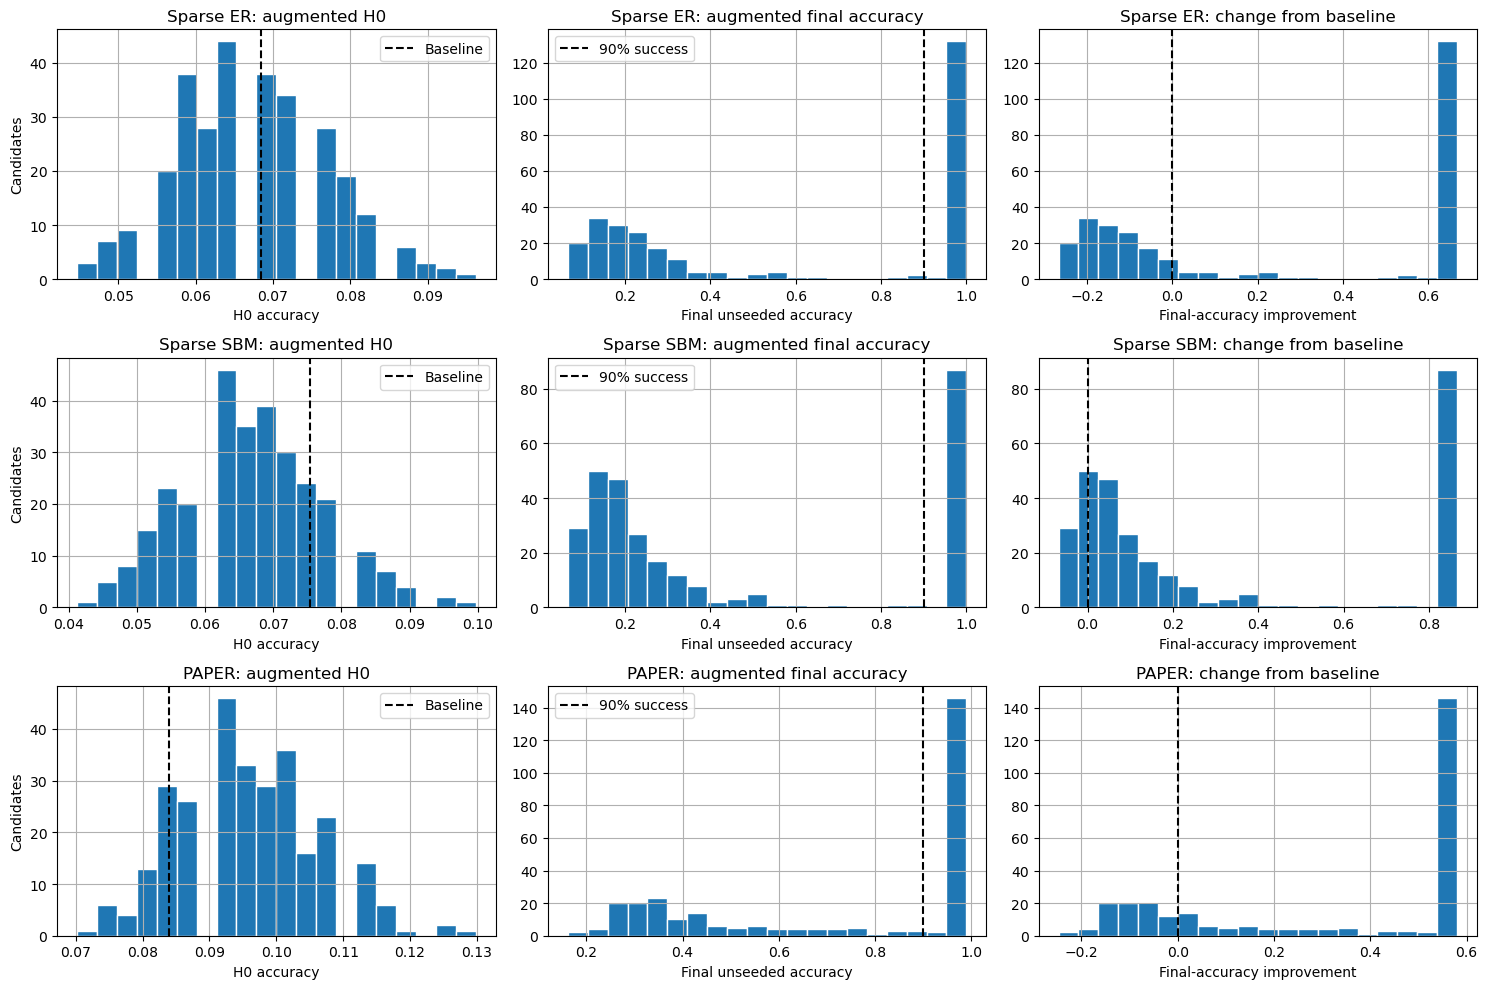

In [20]:
fig, axes = plt.subplots(len(PROBLEMS), 3, figsize=(15, 10))

for row, problem in enumerate(PROBLEMS):
    frame = joined_tables[problem]
    label = PROBLEM_LABELS[problem]

    axes[row, 0].hist(frame["outcome_h0_accuracy"], bins=20, edgecolor="white")
    axes[row, 0].axvline(
        frame["baseline_h0_accuracy"].iloc[0], color="black", linestyle="--", label="Baseline"
    )
    axes[row, 0].set(title=f"{label}: augmented H0", xlabel="H0 accuracy", ylabel="Candidates")
    axes[row, 0].legend()

    axes[row, 1].hist(
        frame["outcome_final_unseeded_accuracy"], bins=20, edgecolor="white"
    )
    axes[row, 1].axvline(SUCCESS_THRESHOLD, color="black", linestyle="--", label="90% success")
    axes[row, 1].set(title=f"{label}: augmented final accuracy", xlabel="Final unseeded accuracy")
    axes[row, 1].legend()

    axes[row, 2].hist(frame["outcome_accuracy_improvement"], bins=20, edgecolor="white")
    axes[row, 2].axvline(0, color="black", linestyle="--")
    axes[row, 2].set(title=f"{label}: change from baseline", xlabel="Final-accuracy improvement")

fig.tight_layout()
plt.show()

## 3. Pre-query feature associations

Candidate identifiers are excluded. Features that are constant within a problem are also removed because they cannot explain which candidate is better for that fixed graph pair and seed set.

In [21]:
IDENTIFIER_COLUMNS = {
    "problem",
    "candidate_vertex_graph1",
    "feature_schema_version",
}
PREQUERY_COLUMNS = [
    column
    for column in feature_tables[PROBLEMS[0]].columns
    if column not in IDENTIFIER_COLUMNS
]

assert not (set(PREQUERY_COLUMNS) & OUTCOME_ONLY_COLUMNS)


def predictor_columns_for_problem(problem_frame):
    columns = []
    for column in PREQUERY_COLUMNS:
        series = problem_frame[column]
        if (
            pd.api.types.is_numeric_dtype(series)
            and series.notna().any()
            and series.nunique(dropna=True) > 1
        ):
            columns.append(column)
    return columns


predictor_columns = {
    problem: predictor_columns_for_problem(joined_tables[problem])
    for problem in PROBLEMS
}

pd.Series(
    {PROBLEM_LABELS[problem]: len(columns) for problem, columns in predictor_columns.items()},
    name="varying_prequery_predictors",
).to_frame()

,varying_prequery_predictors
Sparse ER,38
Sparse SBM,35
PAPER,37


In [22]:
ASSOCIATION_TARGETS = (
    "outcome_h0_accuracy",
    "outcome_final_unseeded_accuracy",
    "outcome_accuracy_improvement",
)

association_rows = []
for problem in PROBLEMS:
    frame = joined_tables[problem]
    for target in ASSOCIATION_TARGETS:
        correlations = frame[predictor_columns[problem]].corrwith(
            frame[target], method="spearman"
        )
        for feature, correlation in correlations.items():
            association_rows.append(
                {
                    "problem": problem,
                    "target": target,
                    "feature": feature,
                    "spearman": correlation,
                    "absolute_spearman": abs(correlation),
                }
            )

association_table = pd.DataFrame(association_rows)
top_associations = (
    association_table.sort_values(
        ["problem", "target", "absolute_spearman"],
        ascending=[True, True, False],
    )
    .groupby(["problem", "target"], sort=False)
    .head(10)
)

for problem in PROBLEMS:
    print(PROBLEM_LABELS[problem])
    display(
        top_associations.loc[
            top_associations["problem"] == problem,
            ["target", "feature", "spearman"],
        ].reset_index(drop=True)
    )

Sparse ER


,target,feature,spearman
0,outcome_accuracy_improvement,candidate_new_two_coverage_count,0.118899
1,outcome_accuracy_improvement,candidate_seed_neighborhood_jaccard_mean,0.101149
2,outcome_accuracy_improvement,candidate_seed_neighborhood_jaccard_max,0.093799
3,outcome_accuracy_improvement,candidate_delta_nonseed_expected_witness_margi...,0.083682
4,outcome_accuracy_improvement,candidate_pagerank,0.082737
5,outcome_accuracy_improvement,candidate_delta_nonseed_seed_signature_unique_...,0.082359
6,outcome_accuracy_improvement,candidate_component_size_fraction,-0.078772
7,outcome_accuracy_improvement,candidate_existing_seeds_in_component,-0.078772
8,outcome_accuracy_improvement,candidate_nonseed_distance_disconnected_fraction,0.078772
9,outcome_accuracy_improvement,candidate_degree,0.071707


Sparse SBM


,target,feature,spearman
0,outcome_accuracy_improvement,candidate_core_number,0.157530
1,outcome_accuracy_improvement,candidate_delta_nonseed_robust_signature_fraction,-0.108574
2,outcome_accuracy_improvement,candidate_delta_nonseed_expected_witness_margi...,0.108440
3,outcome_accuracy_improvement,candidate_clustering,0.108391
4,outcome_accuracy_improvement,candidate_delta_nonseed_seed_signature_unique_...,0.107637
5,outcome_accuracy_improvement,candidate_nonseed_distance_q90,-0.105722
6,outcome_accuracy_improvement,candidate_new_two_coverage_count,0.098202
7,outcome_accuracy_improvement,candidate_nonseed_within_three_hops_fraction,0.093658
8,outcome_accuracy_improvement,candidate_distance_reduction_max,0.093080
9,outcome_accuracy_improvement,candidate_radius_two_new_two_coverage_count,0.090328


PAPER


,target,feature,spearman
0,outcome_accuracy_improvement,candidate_radius_two_new_two_coverage_count,0.198832
1,outcome_accuracy_improvement,candidate_nonseed_within_two_hops_fraction,0.174536
2,outcome_accuracy_improvement,candidate_core_number,0.174283
3,outcome_accuracy_improvement,candidate_nonseed_distance_mean,-0.172461
4,outcome_accuracy_improvement,candidate_delta_nonseed_distance_signature_uni...,-0.170966
5,outcome_accuracy_improvement,candidate_nonseed_within_three_hops_fraction,0.169288
6,outcome_accuracy_improvement,candidate_nonseed_distance_q90,-0.154819
7,outcome_accuracy_improvement,candidate_degree,0.148233
8,outcome_accuracy_improvement,candidate_degree_percentile,0.148233
9,outcome_accuracy_improvement,candidate_delta_nonseed_expected_witness_margi...,0.143251


In [ ]:
PRIMARY_TARGET = "outcome_final_unseeded_accuracy"
top_scatter_features = {
    problem: (
        association_table.loc[
            (association_table["problem"] == problem)
            & (association_table["target"] == PRIMARY_TARGET)
        ]
        .nlargest(3, "absolute_spearman")["feature"]
        .tolist()
    )
    for problem in PROBLEMS
}

fig, axes = plt.subplots(len(PROBLEMS), 3, figsize=(15, 10))
for row, problem in enumerate(PROBLEMS):
    frame = joined_tables[problem]
    for column, feature in enumerate(top_scatter_features[problem]):
        colors = np.where(frame["outcome_success"], "tab:blue", "tab:orange")
        axes[row, column].scatter(
            frame[feature], frame[PRIMARY_TARGET], c=colors, alpha=0.65, s=22
        )
        axes[row, column].axhline(SUCCESS_THRESHOLD, color="black", linestyle="--")
        axes[row, column].set(
            title=f"{PROBLEM_LABELS[problem]}: {feature}",
            xlabel=feature,
            ylabel="Final unseeded accuracy",
        )

fig.tight_layout()
plt.show()

## 4. Exploratory train/test split

Each problem is split independently, with 70% of its candidates used for training and 30% held out. Stratification preserves the success/failure balance. This tests whether candidate-level patterns within the same fixed problem can predict unseen candidate outcomes. Once more graph pairs are collected, replace this with grouped validation that holds out entire graph pairs and base seed sets.

In [ ]:
def make_regressor():
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    min_samples_leaf=5,
                    max_features=0.7,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def make_classifier():
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    min_samples_leaf=5,
                    max_features=0.7,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


splits = {}
for problem in PROBLEMS:
    frame = joined_tables[problem]
    train_index, test_index = train_test_split(
        frame.index,
        test_size=TEST_FRACTION,
        random_state=RANDOM_STATE,
        stratify=frame["outcome_success"],
    )
    splits[problem] = (train_index, test_index)

split_summary = pd.DataFrame(
    {
        "problem": problem,
        "training_candidates": len(splits[problem][0]),
        "test_candidates": len(splits[problem][1]),
        "training_success_rate": joined_tables[problem].loc[
            splits[problem][0], "outcome_success"
        ].mean(),
        "test_success_rate": joined_tables[problem].loc[
            splits[problem][1], "outcome_success"
        ].mean(),
    }
    for problem in PROBLEMS
)
split_summary

## 5. Regression

In [ ]:
REGRESSION_TARGETS = (
    "outcome_h0_accuracy",
    "outcome_final_unseeded_accuracy",
    "outcome_accuracy_improvement",
)

regression_models = {}
regression_predictions = {}
regression_rows = []

for problem in PROBLEMS:
    frame = joined_tables[problem]
    columns = predictor_columns[problem]
    train_index, test_index = splits[problem]
    X_train = frame.loc[train_index, columns].replace([np.inf, -np.inf], np.nan)
    X_test = frame.loc[test_index, columns].replace([np.inf, -np.inf], np.nan)

    for target in REGRESSION_TARGETS:
        y_train = frame.loc[train_index, target]
        y_test = frame.loc[test_index, target]

        model = make_regressor()
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)
        baseline_prediction = np.repeat(y_train.mean(), len(y_test))

        regression_models[(problem, target)] = model
        regression_predictions[(problem, target)] = pd.Series(
            prediction, index=test_index, name="prediction"
        )

        for model_name, values in (
            ("Mean baseline", baseline_prediction),
            ("Random forest", prediction),
        ):
            spearman = pd.Series(y_test.to_numpy()).corr(
                pd.Series(values), method="spearman"
            )
            regression_rows.append(
                {
                    "problem": problem,
                    "target": target,
                    "model": model_name,
                    "MAE": mean_absolute_error(y_test, values),
                    "RMSE": np.sqrt(mean_squared_error(y_test, values)),
                    "R_squared": r2_score(y_test, values),
                    "Spearman": spearman,
                }
            )

regression_results = pd.DataFrame(regression_rows)
regression_results.round(4)

In [ ]:
fig, axes = plt.subplots(1, len(PROBLEMS), figsize=(15, 4.5))

for ax, problem in zip(axes, PROBLEMS):
    frame = joined_tables[problem]
    test_index = splits[problem][1]
    actual = frame.loc[test_index, PRIMARY_TARGET]
    predicted = regression_predictions[(problem, PRIMARY_TARGET)]

    lower = min(actual.min(), predicted.min())
    upper = max(actual.max(), predicted.max())
    ax.scatter(actual, predicted, alpha=0.75)
    ax.plot([lower, upper], [lower, upper], color="black", linestyle="--")
    ax.set(
        title=PROBLEM_LABELS[problem],
        xlabel="Observed final accuracy",
        ylabel="Predicted final accuracy",
    )

fig.suptitle("Random-forest regression on held-out candidates", y=1.02)
fig.tight_layout()
plt.show()

## 6. Classification

In [ ]:
classification_models = {}
classification_predictions = {}
classification_rows = []

for problem in PROBLEMS:
    frame = joined_tables[problem]
    columns = predictor_columns[problem]
    train_index, test_index = splits[problem]
    X_train = frame.loc[train_index, columns].replace([np.inf, -np.inf], np.nan)
    X_test = frame.loc[test_index, columns].replace([np.inf, -np.inf], np.nan)
    y_train = frame.loc[train_index, "outcome_success"]
    y_test = frame.loc[test_index, "outcome_success"]

    model = make_classifier()
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.5).astype(int)

    baseline_probability = np.repeat(y_train.mean(), len(y_test))
    baseline_prediction = np.repeat(int(y_train.mean() >= 0.5), len(y_test))

    classification_models[problem] = model
    classification_predictions[problem] = pd.Series(
        probability, index=test_index, name="success_probability"
    )

    for model_name, labels, probabilities in (
        ("Class-prior baseline", baseline_prediction, baseline_probability),
        ("Random forest", prediction, probability),
    ):
        classification_rows.append(
            {
                "problem": problem,
                "model": model_name,
                "balanced_accuracy": balanced_accuracy_score(y_test, labels),
                "ROC_AUC": roc_auc_score(y_test, probabilities),
                "average_precision": average_precision_score(y_test, probabilities),
            }
        )

classification_results = pd.DataFrame(classification_rows)
classification_results.round(4)

In [ ]:
fig, axes = plt.subplots(2, len(PROBLEMS), figsize=(15, 8))

for column, problem in enumerate(PROBLEMS):
    frame = joined_tables[problem]
    test_index = splits[problem][1]
    y_test = frame.loc[test_index, "outcome_success"]
    probability = classification_predictions[problem]

    RocCurveDisplay.from_predictions(y_test, probability, ax=axes[0, column])
    axes[0, column].plot([0, 1], [0, 1], color="black", linestyle="--")
    axes[0, column].set_title(f"{PROBLEM_LABELS[problem]}: ROC")

    PrecisionRecallDisplay.from_predictions(y_test, probability, ax=axes[1, column])
    axes[1, column].axhline(y_test.mean(), color="black", linestyle="--")
    axes[1, column].set_title(f"{PROBLEM_LABELS[problem]}: precision-recall")

fig.tight_layout()
plt.show()

## 7. Feature importance

Permutation importance measures the loss in held-out performance after a feature is shuffled. Correlated features can divide importance among themselves, so interpret feature groups as well as individual rankings.

In [ ]:
importance_rows = []

for problem in PROBLEMS:
    frame = joined_tables[problem]
    columns = predictor_columns[problem]
    test_index = splits[problem][1]
    X_test = frame.loc[test_index, columns].replace([np.inf, -np.inf], np.nan)

    regression_importance = permutation_importance(
        regression_models[(problem, PRIMARY_TARGET)],
        X_test,
        frame.loc[test_index, PRIMARY_TARGET],
        scoring="neg_mean_absolute_error",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    classification_importance = permutation_importance(
        classification_models[problem],
        X_test,
        frame.loc[test_index, "outcome_success"],
        scoring="roc_auc",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    for model_name, result in (
        ("Final-accuracy regression", regression_importance),
        ("Success classification", classification_importance),
    ):
        for feature, mean, std in zip(
            columns, result.importances_mean, result.importances_std
        ):
            importance_rows.append(
                {
                    "problem": problem,
                    "model": model_name,
                    "feature": feature,
                    "importance_mean": mean,
                    "importance_std": std,
                }
            )

importance_table = pd.DataFrame(importance_rows)
top_importance = (
    importance_table.sort_values(
        ["problem", "model", "importance_mean"], ascending=[True, True, False]
    )
    .groupby(["problem", "model"], sort=False)
    .head(12)
)

for problem in PROBLEMS:
    print(PROBLEM_LABELS[problem])
    display(
        top_importance.loc[
            top_importance["problem"] == problem,
            ["model", "feature", "importance_mean", "importance_std"],
        ].reset_index(drop=True)
    )

In [ ]:
fig, axes = plt.subplots(len(PROBLEMS), 2, figsize=(15, 15))
model_names = ("Final-accuracy regression", "Success classification")

for row, problem in enumerate(PROBLEMS):
    for column, model_name in enumerate(model_names):
        subset = (
            importance_table.loc[
                (importance_table["problem"] == problem)
                & (importance_table["model"] == model_name)
            ]
            .nlargest(10, "importance_mean")
            .sort_values("importance_mean")
        )
        axes[row, column].barh(
            subset["feature"],
            subset["importance_mean"],
            xerr=subset["importance_std"],
            alpha=0.8,
        )
        axes[row, column].axvline(0, color="black", linewidth=1)
        axes[row, column].set(
            title=f"{PROBLEM_LABELS[problem]}: {model_name}",
            xlabel="Permutation importance",
        )

fig.tight_layout()
plt.show()

## 8. Candidate ranking

The operational decision is to select one candidate. The table below compares the top candidate chosen by each learned model with three pre-query heuristics. The oracle uses the observed outcomes and is included only as an upper bound. The random row is the expected result of selecting uniformly from the held-out candidates.

`regret_to_oracle` is the best held-out final accuracy minus the final accuracy achieved by the selected candidate. Lower regret is better.

In [ ]:
ranking_frames = {}
selection_rows = []
ranking_quality_rows = []
top_k_rows = []

HEURISTICS = {
    "Highest degree": "candidate_degree",
    "Most new one-hop coverage": "candidate_new_coverage_count",
    "Most new one-hop two-coverage": "candidate_new_two_coverage_count",
    "Most new radius-2 coverage": "candidate_radius_two_new_coverage_count",
    "Most new radius-2 two-coverage": (
        "candidate_radius_two_new_two_coverage_count"
    ),
    "Largest mean distance reduction": "candidate_distance_reduction_mean",
}
TOP_K_VALUES = (1, 3, 5, 10)


def highest_scoring_row(frame, score_column):
    return frame.sort_values(
        [score_column, "candidate_vertex_graph1"],
        ascending=[False, True],
    ).iloc[0]


for problem in PROBLEMS:
    frame = joined_tables[problem]
    columns = predictor_columns[problem]
    test_index = splits[problem][1]
    test = frame.loc[test_index].copy()
    X_test = test[columns].replace([np.inf, -np.inf], np.nan)

    test["predicted_final_accuracy"] = regression_models[
        (problem, PRIMARY_TARGET)
    ].predict(X_test)
    test["predicted_success_probability"] = classification_models[
        problem
    ].predict_proba(X_test)[:, 1]
    test["actual_final_rank"] = test[PRIMARY_TARGET].rank(
        method="min", ascending=False
    )
    ranking_frames[problem] = test

    oracle_accuracy = test[PRIMARY_TARGET].max()

    selection_rows.append(
        {
            "problem": problem,
            "method": "Random expectation",
            "candidate_vertex_graph1": np.nan,
            "observed_h0": test["outcome_h0_accuracy"].mean(),
            "observed_final": test[PRIMARY_TARGET].mean(),
            "observed_improvement": test["outcome_accuracy_improvement"].mean(),
            "success_or_expected_rate": test["outcome_success"].mean(),
            "actual_final_rank": np.nan,
            "regret_to_oracle": oracle_accuracy - test[PRIMARY_TARGET].mean(),
        }
    )

    scoring_methods = {
        "Regression model": "predicted_final_accuracy",
        "Classification model": "predicted_success_probability",
        **HEURISTICS,
        "Oracle upper bound": PRIMARY_TARGET,
    }

    for method, score_column in scoring_methods.items():
        selected = highest_scoring_row(test, score_column)
        selection_rows.append(
            {
                "problem": problem,
                "method": method,
                "candidate_vertex_graph1": int(selected["candidate_vertex_graph1"]),
                "observed_h0": selected["outcome_h0_accuracy"],
                "observed_final": selected[PRIMARY_TARGET],
                "observed_improvement": selected["outcome_accuracy_improvement"],
                "success_or_expected_rate": selected["outcome_success"],
                "actual_final_rank": selected["actual_final_rank"],
                "regret_to_oracle": oracle_accuracy - selected[PRIMARY_TARGET],
            }
        )

    for model_name, score_column in (
        ("Regression model", "predicted_final_accuracy"),
        ("Classification model", "predicted_success_probability"),
    ):
        ranking_quality_rows.append(
            {
                "problem": problem,
                "model": model_name,
                "Spearman_with_final_accuracy": test[score_column].corr(
                    test[PRIMARY_TARGET], method="spearman"
                ),
                "NDCG": ndcg_score(
                    [test[PRIMARY_TARGET].to_numpy()],
                    [test[score_column].to_numpy()],
                ),
            }
        )

        ranked = test.sort_values(score_column, ascending=False)
        for requested_k in TOP_K_VALUES:
            k = min(requested_k, len(ranked))
            shortlist = ranked.head(k)
            best_shortlist_accuracy = shortlist[PRIMARY_TARGET].max()
            top_k_rows.append(
                {
                    "problem": problem,
                    "model": model_name,
                    "k": k,
                    "contains_success": bool(shortlist["outcome_success"].any()),
                    "best_final_accuracy_in_top_k": best_shortlist_accuracy,
                    "mean_final_accuracy_in_top_k": shortlist[PRIMARY_TARGET].mean(),
                    "best_in_top_k_regret": oracle_accuracy - best_shortlist_accuracy,
                }
            )

selection_summary = pd.DataFrame(selection_rows)
ranking_quality = pd.DataFrame(ranking_quality_rows)
top_k_summary = pd.DataFrame(top_k_rows)

display(selection_summary.round(4))
display(ranking_quality.round(4))
display(top_k_summary.round(4))

In [ ]:
CANDIDATE_COLUMNS_TO_SHOW = [
    "candidate_vertex_graph1",
    "predicted_final_accuracy",
    "predicted_success_probability",
    "outcome_h0_accuracy",
    "outcome_final_unseeded_accuracy",
    "outcome_accuracy_improvement",
    "outcome_success",
    "candidate_degree",
    "candidate_edges_to_existing_seeds",
    "candidate_new_coverage_count",
    "candidate_new_two_coverage_count",
    "candidate_nonseed_distance_mean",
    "candidate_becomes_nearest_seed_fraction",
    "candidate_distance_reduction_mean",
    "candidate_radius_two_new_coverage_count",
    "candidate_radius_two_new_two_coverage_count",
]

for problem in PROBLEMS:
    print(f"{PROBLEM_LABELS[problem]}: top 10 candidates by predicted final accuracy")
    display(
        ranking_frames[problem]
        .sort_values("predicted_final_accuracy", ascending=False)
        [CANDIDATE_COLUMNS_TO_SHOW]
        .head(10)
        .round(4)
    )

## Reading the results

- Compare the random forest with its baseline before interpreting feature importance.
- For $H_0$, focus on MAE and rank correlation when its variance is small; $R^2$ can become unstable for a nearly constant target.
- Classification ROC AUC measures ordering across all thresholds. Average precision is especially helpful when successful candidates are uncommon.
- For choosing one query, inspect the selected candidate's realized accuracy and regret. For producing a shortlist, inspect top-$k$ success and top-$k$ regret.
- Agreement of important features across ER, SBM, and PAPER is stronger evidence than a large importance in only one fixed instance.
- The revealed Graph B candidate and all SGM outcome columns are excluded from predictors throughout the notebook.